<a href="https://colab.research.google.com/github/madhumitha-gv/LLMs/blob/main/Catastrophic_forgetting_with_MMLU_unsloth.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install "unsloth[colab-new] @ git+https://github.com/unslothai/unsloth.git"
!pip install --no-deps trl peft accelerate bitsandbytes

  Cloning https://github.com/unslothai/unsloth.git to /tmp/pip-install-midpfmgg/unsloth_c6cda8b1198544d28c641b162ddf2f61
  Running command git clone --filter=blob:none --quiet https://github.com/unslothai/unsloth.git /tmp/pip-install-midpfmgg/unsloth_c6cda8b1198544d28c641b162ddf2f61
  Resolved https://github.com/unslothai/unsloth.git to commit df3a205726d231bd12402960a3cd3a90b85c7fc7
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


# Imports and configs

In [ ]:
import torch
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset, concatenate_datasets
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    BitsAndBytesConfig,
    TrainingArguments,
)
from peft import (
    LoraConfig,
    get_peft_model,
    prepare_model_for_kbit_training,
)
from trl import SFTTrainer

# ── Config ─────────────────────────────────────────────────────────
MODEL_ID = "mistralai/Mistral-7B-Instruct-v0.2"

PHYSICS_SUBJECTS = [
    "college_physics",
    "high_school_physics",
    "conceptual_physics",
]
BIOLOGY_SUBJECTS = [
    "college_biology",
    "high_school_biology",
    "medical_genetics",
]

TRAIN_RATIO   = 0.80   # 80% of each subject for training
REPLAY_RATIO  = 0.25   # 25% biology mixed into physics during replay
MAX_LENGTH    = 512
LORA_R        = 16
LORA_ALPHA    = 32
LORA_DROPOUT  = 0.05
NUM_EPOCHS = 3
LR         = 5e-5    # was 2e-4, 4x lower
BATCH_SIZE = 4
SEED          = 42

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device : {DEVICE}")
print(f"GPU    : {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'None'}")

Device : cuda
GPU    : NVIDIA A100-SXM4-40GB


In [ ]:
from google.colab import drive
drive.mount("/content/drive")

import os
SAVE_DIR = "/content/drive/MyDrive/Catastrophic_forgetting_unsloth"
os.makedirs(SAVE_DIR, exist_ok=True)
print(f"Save directory: {SAVE_DIR}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Save directory: /content/drive/MyDrive/Catastrophic_forgetting_unsloth


# Build datasets

In [ ]:
LETTERS = ["A", "B", "C", "D"]

def format_prompt(example):
    """
    Convert one MMLU example into Mistral instruction format.

    Input:
        question : "What is..."
        choices  : ["opt1", "opt2", "opt3", "opt4"]
        answer   : 2  (index, so correct answer is C)

    Output:
        text: "<s>[INST] Question: What is...
               (A) opt1
               (B) opt2
               (C) opt3
               (D) opt4
               Answer with only the letter. [/INST] C</s>"
    """
    choices_str = "\n".join(
        f"({LETTERS[i]}) {example['choices'][i]}"
        for i in range(4)
    )
    text = (
        f"<s>[INST] Question: {example['question']}\n"
        f"{choices_str}\n"
        f"Answer with only the letter. [/INST] "
        f"{LETTERS[example['answer']]}</s>"
    )
    return {"text": text}


def build_datasets(subjects, train_ratio=TRAIN_RATIO, seed=SEED):
    """
    Load MMLU test split for each subject, format prompts,
    then split 80/20 into train and eval.

    Returns:
        train_ds : combined training dataset (pure subject, no leakage)
        eval_ds  : combined eval dataset (held out forever)
    """
    all_train = []
    all_eval  = []

    for subject in subjects:
        # Load only the test split — clean subject-specific questions
        ds = load_dataset("cais/mmlu", subject, split="test")
        ds = ds.map(format_prompt)

        # 80/20 split — reproducible with fixed seed
        split    = ds.train_test_split(
            test_size=1 - train_ratio,
            seed=seed
        )
        train_ds = split["train"]
        eval_ds  = split["test"]

        all_train.append(train_ds)
        all_eval.append(eval_ds)

        print(f"  {subject}: {len(train_ds)} train | {len(eval_ds)} eval")

    combined_train = concatenate_datasets(all_train).shuffle(seed=seed)
    combined_eval  = concatenate_datasets(all_eval)

    print(f"  → Total train: {len(combined_train)} | eval: {len(combined_eval)}\n")
    return combined_train, combined_eval


print("Building Physics datasets...")
physics_train, physics_eval = build_datasets(PHYSICS_SUBJECTS)

print("Building Biology datasets...")
biology_train, biology_eval = build_datasets(BIOLOGY_SUBJECTS)

# Save dataset sizes for report
dataset_info = {
    "physics_train" : len(physics_train),
    "physics_eval"  : len(physics_eval),
    "biology_train" : len(biology_train),
    "biology_eval"  : len(biology_eval),
}
print("Dataset summary:", dataset_info)

Building Physics datasets...
  college_physics: 81 train | 21 eval
  high_school_physics: 120 train | 31 eval
  conceptual_physics: 188 train | 47 eval
  → Total train: 389 | eval: 99

Building Biology datasets...
  college_biology: 115 train | 29 eval
  high_school_biology: 248 train | 62 eval
  medical_genetics: 80 train | 20 eval
  → Total train: 443 | eval: 111

Dataset summary: {'physics_train': 389, 'physics_eval': 99, 'biology_train': 443, 'biology_eval': 111}


In [ ]:
from unsloth import FastLanguageModel
import torch

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name="mistralai/Mistral-7B-Instruct-v0.2",
    max_seq_length=320,
    dtype=torch.bfloat16,
    load_in_4bit=False,
)
tokenizer.pad_token    = tokenizer.eos_token
tokenizer.padding_side = "right"
print(f"GPU memory used: {torch.cuda.memory_allocated()/1e9:.2f} GB")

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.


/tmp/ipykernel_14876/1533954115.py:1: UserWarning: WARNING: Unsloth should be imported before [trl, transformers, peft] to ensure all optimizations are applied. Your code may run slower or encounter memory issues without these optimizations.

Please restructure your imports with 'import unsloth' at the top of your file.
  from unsloth import FastLanguageModel


Unsloth: Your Flash Attention 2 installation seems to be broken. Using Xformers instead. No performance changes will be seen.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.4.8: Fast Mistral patching. Transformers: 5.5.0.
   \\   /|    NVIDIA A100-SXM4-40GB. Num GPUs = 1. Max memory: 39.494 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 8.0. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

GPU memory used: 14.53 GB


In [ ]:
model = FastLanguageModel.get_peft_model(
    model,
    r=128,
    lora_alpha=256,
    lora_dropout=0.05,
    target_modules=[
        "q_proj", "k_proj", "v_proj", "o_proj",
        "gate_proj", "up_proj", "down_proj",
    ],
    bias="none",
    use_gradient_checkpointing="unsloth",
    random_state=42,
)

Unsloth: Already have LoRA adapters! We shall skip this step.


#

#Evaluation Function

In [ ]:
def evaluate(model, tokenizer, eval_dataset, label, max_samples=None):
    """
    Evaluate model on MMLU eval set using logit-based answer selection.

    For each question, looks at model confidence for tokens A/B/C/D
    and picks the highest — no generation needed.

    Args:
        model       : the current model (base or fine-tuned)
        tokenizer   : Mistral tokenizer
        eval_dataset: held-out eval set (never trained on)
        label       : string label for printing e.g. "Physics"
        max_samples : optional cap for speed during debugging

    Returns:
        accuracy (float), correct (int), total (int)
    """
    model.eval()

    # Get the token IDs for " A", " B", " C", " D"
    # Space before letter is important — matches tokenization
    answer_token_ids = [
        tokenizer(" A", add_special_tokens=False).input_ids[-1],
        tokenizer(" B", add_special_tokens=False).input_ids[-1],
        tokenizer(" C", add_special_tokens=False).input_ids[-1],
        tokenizer(" D", add_special_tokens=False).input_ids[-1],
    ]

    samples = eval_dataset
    if max_samples:
        samples = eval_dataset.select(range(min(max_samples, len(eval_dataset))))

    correct = 0
    total   = 0

    with torch.no_grad():
        for example in samples:
            # Rebuild prompt WITHOUT the answer
            choices_str = "\n".join(
                f"({LETTERS[i]}) {example['choices'][i]}"
                for i in range(4)
            )
            prompt = (
                f"<s>[INST] Question: {example['question']}\n"
                f"{choices_str}\n"
                f"Answer with only the letter. [/INST]"
            )

            inputs = tokenizer(
                prompt,
                return_tensors="pt",
                truncation=True,
                max_length=MAX_LENGTH,
            ).to(DEVICE)

            outputs = model(**inputs)

            # Logits at the last token position — model predicts next token
            last_logits = outputs.logits[0, -1, :]

            # Extract scores for only A B C D
            abcd_logits = torch.tensor(
                [last_logits[tid] for tid in answer_token_ids]
            )
            predicted = abcd_logits.argmax().item()

            if predicted == example["answer"]:
                correct += 1
            total += 1

    accuracy = correct / total
    print(f"  {label}: {accuracy:.1%} ({correct}/{total})")
    return accuracy, correct, total

In [ ]:
from trl import SFTTrainer, SFTConfig

def train_model(model, tokenizer, train_dataset, output_dir, epochs=NUM_EPOCHS):
    args = SFTConfig(
        output_dir=output_dir,
        num_train_epochs=epochs,
        per_device_train_batch_size=BATCH_SIZE,
        gradient_accumulation_steps=4,
        learning_rate=LR,
        bf16=True,
        fp16=False,
        logging_steps=10,
        save_strategy="no",
        warmup_steps=20,
        lr_scheduler_type="cosine",
        report_to="none",
        packing=False,
    )
    trainer = SFTTrainer(
        model=model,
        args=args,
        train_dataset=train_dataset,
        processing_class=tokenizer,
    )
    trainer.train()
    return model

#Run All Phases

In [ ]:
results = {}
print("=" * 55)
print("PHASE 1 — Baseline")
print("=" * 55)
p_acc, p_c, p_t = evaluate(model, tokenizer, physics_eval, "Physics")
b_acc, b_c, b_t = evaluate(model, tokenizer, biology_eval, "Biology")
results["Baseline"] = {"Physics": round(p_acc, 4), "Biology": round(b_acc, 4)}

with open(f"{SAVE_DIR}/results.json", "w") as f:
    json.dump(results, f, indent=2)
print("Checkpoint saved.")

#

`use_return_dict` is deprecated! Use `return_dict` instead!


PHASE 1 — Baseline


/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:254: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API 

  Physics: 40.4% (40/99)
  Biology: 67.6% (75/111)
Checkpoint saved.


In [ ]:
print("=" * 55)
print("PHASE 2 — Fine-tune on Physics only")
print("=" * 55)

model = train_model(
    model, tokenizer, physics_train,
    output_dir=f"{SAVE_DIR}/phase2_physics"
)

p_acc, p_c, p_t = evaluate(model, tokenizer, physics_eval, "Physics")
b_acc, b_c, b_t = evaluate(model, tokenizer, biology_eval, "Biology")
results["After Physics FT"] = {"Physics": round(p_acc, 4), "Biology": round(b_acc, 4)}

with open(f"{SAVE_DIR}/results.json", "w") as f:
    json.dump(results, f, indent=2)
print("Checkpoint saved.")

PHASE 2 — Fine-tune on Physics only


Unsloth: Tokenizing ["text"] (num_proc=16):   0%|          | 0/389 [00:00<?, ? examples/s]

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'pad_token_id': 2}.


🦥 Unsloth: Padding-free auto-enabled, enabling faster training.


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 389 | Num Epochs = 3 | Total steps = 75
O^O/ \_/ \    Batch size per device = 4 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (4 x 4 x 1) = 16
 "-____-"     Trainable parameters = 335,544,320 of 7,577,276,416 (4.43% trained)


Step,Training Loss
10,2.640935
20,1.314278
30,0.852561
40,0.667651
50,0.573476


Step,Training Loss
10,2.640935
20,1.314278
30,0.852561
40,0.667651
50,0.573476
60,0.305277
70,0.256830


/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:254: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API 

  Physics: 41.4% (41/99)
  Biology: 59.5% (66/111)
Checkpoint saved.


In [ ]:
print("=" * 55)
print("PHASE 3 — Replay (Physics + 25% Biology)")
print("=" * 55)

n_bio      = int(len(physics_train) * REPLAY_RATIO)
bio_subset = biology_train.select(range(n_bio))
replay_ds  = concatenate_datasets([physics_train, bio_subset]).shuffle(seed=SEED)
print(f"Replay mix: {len(physics_train)} physics + {n_bio} biology = {len(replay_ds)} total")

model = train_model(
    model, tokenizer, replay_ds,
    output_dir=f"{SAVE_DIR}/phase3_replay"
)

p_acc, p_c, p_t = evaluate(model, tokenizer, physics_eval, "Physics")
b_acc, b_c, b_t = evaluate(model, tokenizer, biology_eval, "Biology")
results["After Replay"] = {"Physics": round(p_acc, 4), "Biology": round(b_acc, 4)}

with open(f"{SAVE_DIR}/results.json", "w") as f:
    json.dump(results, f, indent=2)
print("All results saved.")
print(json.dumps(results, indent=2))

PHASE 3 — Replay (Physics + 25% Biology)
Replay mix: 389 physics + 97 biology = 486 total


Unsloth: Tokenizing ["text"] (num_proc=16):   0%|          | 0/486 [00:00<?, ? examples/s]

==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 486 | Num Epochs = 3 | Total steps = 93
O^O/ \_/ \    Batch size per device = 4 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (4 x 4 x 1) = 16
 "-____-"     Trainable parameters = 335,544,320 of 7,577,276,416 (4.43% trained)


Step,Training Loss
10,0.461994
20,0.451951
30,0.470295
40,0.302650
50,0.229190
60,0.268804
70,0.181500
80,0.134162
90,0.144269


/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:254: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API 

  Physics: 52.5% (52/99)
  Biology: 66.7% (74/111)
All results saved.
{
  "Baseline": {
    "Physics": 0.404,
    "Biology": 0.6757
  },
  "After Physics FT": {
    "Physics": 0.4141,
    "Biology": 0.5946
  },
  "After Replay": {
    "Physics": 0.5253,
    "Biology": 0.6667
  }
}


# Plot results

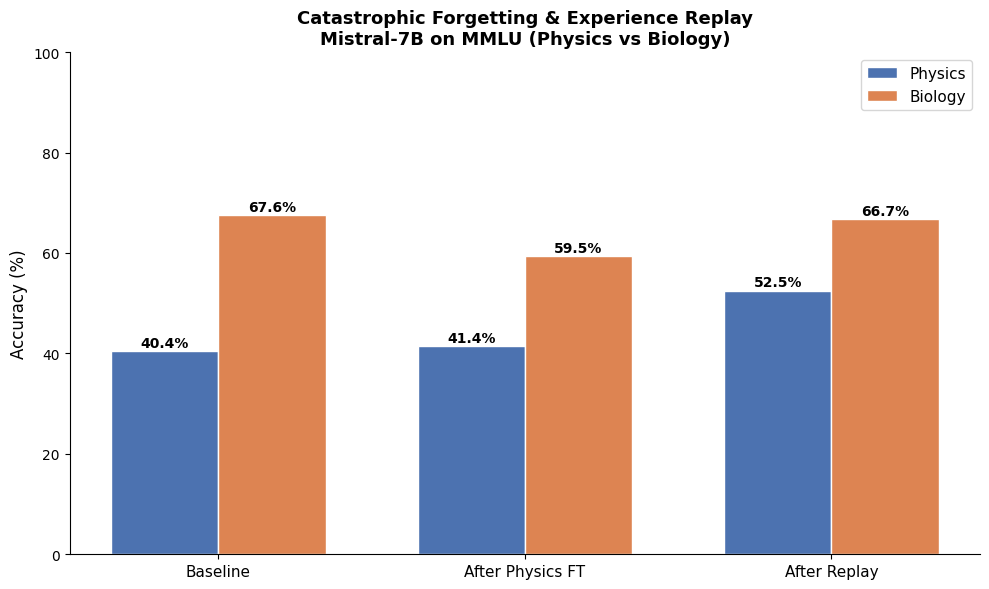

Plot saved to Google Drive.


In [ ]:
phases      = list(results.keys())
phys_scores = [results[p]["Physics"] * 100 for p in phases]
bio_scores  = [results[p]["Biology"]  * 100 for p in phases]

x = np.arange(len(phases))
w = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - w/2, phys_scores, w, label="Physics", color="#4C72B0", edgecolor="white")
bars2 = ax.bar(x + w/2, bio_scores,  w, label="Biology",  color="#DD8452", edgecolor="white")

for bar, val in zip(bars1, phys_scores):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.8,
            f"{val:.1f}%", ha="center", fontsize=10, fontweight="bold")
for bar, val in zip(bars2, bio_scores):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.8,
            f"{val:.1f}%", ha="center", fontsize=10, fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels(phases, fontsize=11)
ax.set_ylabel("Accuracy (%)", fontsize=12)
ax.set_ylim(0, 100)
ax.set_title(
    "Catastrophic Forgetting & Experience Replay\nMistral-7B on MMLU (Physics vs Biology)",
    fontsize=13, fontweight="bold"
)
ax.legend(fontsize=11)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/results_plot.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved to Google Drive.")